In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mbn_preprocess

I0000 00:00:1780464441.841756    5666 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
@tf.keras.utils.register_keras_serializable(package='ph2')
class PreprocessLayer(tf.keras.layers.Layer):
    """Aplica el preprocess_input del backbone correspondiente."""
    def __init__(self, backbone='resnet', **kwargs):
        super().__init__(**kwargs)
        self.backbone = backbone
        
    def call(self, inputs):
        if self.backbone == 'efficientnet':
            return eff_preprocess(inputs)
        elif self.backbone == 'resnet':
            return resnet_preprocess(inputs)
        elif self.backbone == 'mobilenet':
            return mbn_preprocess(inputs)
        else:
            raise ValueError(f"Backbone desconocido: {self.backbone}")
            
    def get_config(self):
        cfg = super().get_config()
        cfg.update({'backbone': self.backbone})
        return cfg

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42
TEST_DIR = "dataset_test_exportado" # <-- Asegúrate de que esta carpeta exista
MODEL_PATH = "modelo_exp7_ultra_regularizado.keras" # <-- Ruta a tu modelo

print(f"Cargando imágenes desde: {TEST_DIR}")
# Cargamos el dataset sin barajar (shuffle=False) para comparar fácilmente y_true con y_pred
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    shuffle=False, 
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

CLASS_NAMES = test_ds.class_names
print(f"Clases detectadas: {CLASS_NAMES}")

print(f"\nCargando modelo desde: {MODEL_PATH}")
model = tf.keras.models.load_model(MODEL_PATH)

# Definimos las capas de Test-Time Augmentation (TTA)
tta_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical", seed=SEED),
    tf.keras.layers.RandomRotation(0.1, seed=SEED),
])

Cargando imágenes desde: dataset_test_exportado
Found 40 files belonging to 3 classes.


I0000 00:00:1780464446.115575    5666 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7496 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1080, pci bus id: 0000:01:00.0, compute capability: 6.1


Clases detectadas: ['Atypical Nevus', 'Common Nevus', 'Melanoma']

Cargando modelo desde: modelo_exp7_ultra_regularizado.keras


In [4]:
def tta_predict(model, dataset, n_augments=8):
    """Promedia predicciones sobre múltiples augmentations de test por lotes."""
    print(f"\nIniciando inferencia TTA con {n_augments} pasadas por imagen...")
    y_true_list = []
    proba_acum = []
    
    for step, (imgs, lbls) in enumerate(dataset):
        y_true_list.extend(lbls.numpy())
        
        # 1. Predicción base (sin augment)
        proba_sum = model.predict(imgs, verbose=0)
        
        # 2. Predicciones con TTA
        for _ in range(n_augments - 1):
            aug_imgs = tta_aug(imgs, training=True)
            proba_sum += model.predict(aug_imgs, verbose=0)
            
        # 3. Promediar
        proba_avg = proba_sum / n_augments
        proba_acum.append(proba_avg)
        
        print(f"  Procesado lote {step + 1}")
        
    return np.array(y_true_list), np.concatenate(proba_acum, axis=0)

y_true, y_proba = tta_predict(model, test_ds, n_augments=8)
y_pred = np.argmax(y_proba, axis=1)


Iniciando inferencia TTA con 8 pasadas por imagen...


I0000 00:00:1780464454.489378    5757 service.cc:153] XLA service 0x7f577c0647b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780464454.489401    5757 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1080, Compute Capability 6.1 (Driver: 13.0.0; Runtime: 12.4.0; Toolkit: 12.5.0; DNN: 9.10.1)
I0000 00:00:1780464454.552541    5757 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780464455.001244    5757 cuda_dnn.cc:461] Loaded cuDNN version 91001
I0000 00:00:1780464458.255977    5757 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Procesado lote 1
  Procesado lote 2
  Procesado lote 3


In [5]:
MELANOMA_IDX = CLASS_NAMES.index('Melanoma')

y_true_bin = (y_true == MELANOMA_IDX).astype(int)
y_pred_bin = (y_pred == MELANOMA_IDX).astype(int)
y_proba_mel = y_proba[:, MELANOMA_IDX]

# Calcular matrices para Sensibilidad y Especificidad
tp = ((y_true_bin == 1) & (y_pred_bin == 1)).sum()
fn = ((y_true_bin == 1) & (y_pred_bin == 0)).sum()
tn = ((y_true_bin == 0) & (y_pred_bin == 0)).sum()
fp = ((y_true_bin == 0) & (y_pred_bin == 1)).sum()

sensibilidad = tp / (tp + fn) if (tp + fn) > 0 else 0.0
especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0.0
auc_mel = roc_auc_score(y_true_bin, y_proba_mel)
f1_mel = f1_score(y_true_bin, y_pred_bin)

print("\n" + "=" * 50)
print(" RESULTADOS DE VALIDACIÓN (Exp 13 - TTA 8 augs)")
print("=" * 50)
print(f"Exactitud Global (Accuracy): {np.mean(y_true == y_pred):.3f}")
print(f"AUC Melanoma:                {auc_mel:.3f}")
print(f"F1-Score Melanoma:           {f1_mel:.3f}")
print(f"Sensibilidad (Recall) Mel:   {sensibilidad*100:.1f}%")
print(f"Especificidad Melanoma:      {especificidad*100:.1f}%")

print("\nReporte Detallado por Clases:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


 RESULTADOS DE VALIDACIÓN (Exp 13 - TTA 8 augs)
Exactitud Global (Accuracy): 0.475
AUC Melanoma:                0.984
F1-Score Melanoma:           0.875
Sensibilidad (Recall) Mel:   87.5%
Especificidad Melanoma:      96.9%

Reporte Detallado por Clases:
                precision    recall  f1-score   support

Atypical Nevus       0.38      0.38      0.38        16
  Common Nevus       0.38      0.38      0.38        16
      Melanoma       0.88      0.88      0.88         8

      accuracy                           0.47        40
     macro avg       0.54      0.54      0.54        40
  weighted avg       0.47      0.47      0.47        40



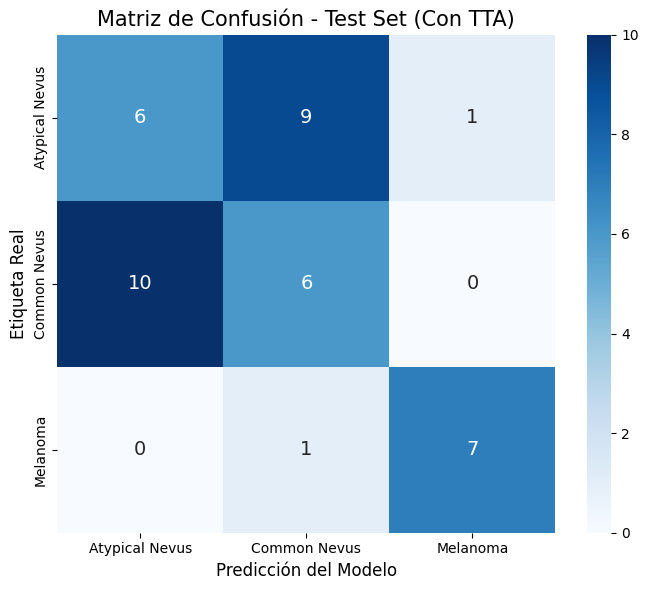

In [6]:
plt.figure(figsize=(7, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            annot_kws={'size': 14})
plt.title('Matriz de Confusión - Test Set (Con TTA)', fontsize=15)
plt.ylabel('Etiqueta Real', fontsize=12)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.tight_layout()
plt.show()